In [ ]:
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import SamplerV2 as Sampler

In [ ]:
QiskitRuntimeService.save_account(channel='ibm_quantum_platform', instance = 'crn:v1:bluemix:public:quantum-computing:us-east:a/7122cb8d4e5148bd8f3a58292620d4cf:abf27454-09ac-4753-a3d0-9b0da10cdf09::', token='7jyKQAGgnppLAdmxUAPQsQDOJ6v00y3-GIQjW42pLazn', overwrite=True, set_as_default=True)
service = QiskitRuntimeService()

backend=service.backend("ibm_marrakesh")
print(backend.name)

sampler=Sampler(mode=backend)

ibm_marrakesh


In [ ]:
from qiskit.primitives import BackendSamplerV2
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel

In [ ]:
noise_model=NoiseModel.from_backend(backend)

In [ ]:
backend_sim=AerSimulator(noise_model=noise_model)
sampler_sim=BackendSamplerV2(backend=backend_sim)

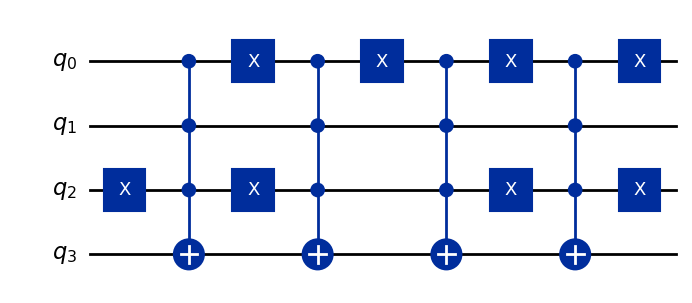

In [ ]:
from qiskit import QuantumCircuit
import numpy as np


def dj(num_qubits):

  qc_dj=QuantumCircuit(num_qubits+1)
  if np.random.randint(0,2):
    qc_dj.x(num_qubits)
  if np.random.randint(0,2):
    return qc_dj

  on_choice=np.random.choice(
      range(2**num_qubits),
      2**num_qubits//2,
      replace=False
  )
  def add_cnot(qc_dj,bit_string):
    for qubit,bit in enumerate(reversed(bit_string)):
      if bit=="1":
        qc_dj.x(qubit)
    return qc_dj

  for state in on_choice:
    qc_dj = add_cnot(qc_dj, f"{state:0b}")
    qc_dj.mcx(list(range(num_qubits)), num_qubits)
    qc_dj = add_cnot(qc_dj, f"{state:0b}")
  return qc_dj

n=3
oracle=dj(n)
display(oracle.draw("mpl"))


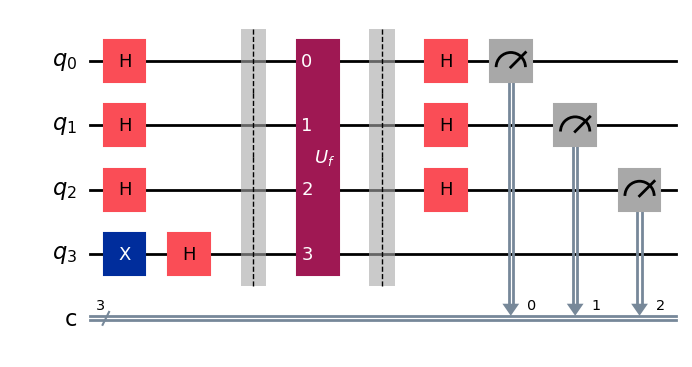

In [ ]:
blackbox = oracle.to_gate()
blackbox.label = "$U_f$"


qc_dj = QuantumCircuit(n + 1, n)
qc_dj.x(n)
qc_dj.h(range(n + 1))
qc_dj.barrier()
qc_dj.compose(blackbox, inplace=True)
qc_dj.barrier()
qc_dj.h(range(n))
qc_dj.measure(range(n), range(n))

qc_dj.decompose().decompose()


qc_dj.draw("mpl")

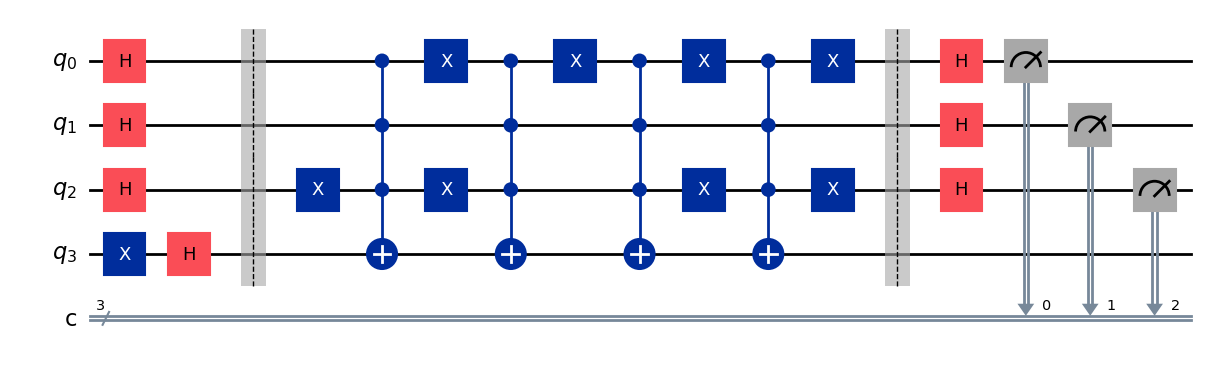

In [ ]:
# Step 1: Map the problem

qc_dj = QuantumCircuit(n + 1, n)
qc_dj.x(n)
qc_dj.h(range(n + 1))
qc_dj.barrier()
qc_dj.compose(oracle, inplace=True)
qc_dj.barrier()
qc_dj.h(range(n))
qc_dj.measure(range(n), range(n))

qc_dj.decompose().decompose()


qc_dj.draw("mpl")

In [ ]:
# Step 2: Transpile
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)

qc_isa = pm.run(qc_dj)

In [ ]:
# Step 3: Run the job on a real quantum computer

job = sampler.run([qc_isa], shots=1)
# job = sampler_sim.run([qc_isa],shots=1) # uncomment this line to run on simulator instead
res = job.result()
counts = res[0].data.c.get_counts()

In [ ]:
# Step 4: Visualize and analyze results

## Analysis
print(counts)

if (
    "0" * n in counts
):  # The D-J algorithm returns all zeroes if the function was constant
    print("constant")
else:
    print("balanced")  # anything other than all zeroes means the function is balanced.

{'010': 1}
balanced
